In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2026)

In [2]:
# Parámetros
N = 100      # estampas diferentes
S = 7        # estampas por sobre
R = 10000    # simulaciones

In [3]:
def simular_album(N, S):
    """
    Simula el llenado de un álbum.

    Parámetros:
        N : total de estampas distintas
        S : estampas por sobre

    Retorna:
        sobres_comprados
        repetidas
    """

    coleccion = set()

    sobres_comprados = 0
    repetidas = 0

    while len(coleccion) < N:

        # Generar un sobre con S estampas distintas
        sobre = np.random.choice(N, size=S, replace=False)

        sobres_comprados += 1

        for estampa in sobre:

            if estampa in coleccion:
                repetidas += 1
            else:
                coleccion.add(estampa)

    return sobres_comprados, repetidas

In [4]:
resultados_sobres = []
resultados_repetidas = []

for _ in range(R):

    sobres, repetidas = simular_album(N, S)

    resultados_sobres.append(sobres)
    resultados_repetidas.append(repetidas)

In [5]:
resultados_sobres = np.array(resultados_sobres)
resultados_repetidas = np.array(resultados_repetidas)

In [6]:
media_sobres = np.mean(resultados_sobres)
std_sobres = np.std(resultados_sobres)

media_repetidas = np.mean(resultados_repetidas)
std_repetidas = np.std(resultados_repetidas)

print("Número de sobres")
print("Media:", media_sobres)
print("Desviación estándar:", std_sobres)

print("\nEstampas repetidas")
print("Media:", media_repetidas)
print("Desviación estándar:", std_repetidas)

Número de sobres
Media: 72.2456
Desviación estándar: 17.471510542594764

Estampas repetidas
Media: 405.7192
Desviación estándar: 122.30057379816334


In [7]:
prob_mas_30 = np.mean(resultados_sobres > 30)

print("Probabilidad de necesitar más de 30 sobres:", prob_mas_30)

Probabilidad de necesitar más de 30 sobres: 1.0


In [8]:
minimo_teorico = int(np.ceil(N / S))

print("Mínimo teórico de sobres:", minimo_teorico)

Mínimo teórico de sobres: 15


In [9]:
H_N = np.sum(1 / np.arange(1, N + 1))

valor_teorico = (N / S) * H_N

print("H_N =", H_N)
print("Valor teórico =", valor_teorico)

H_N = 5.187377517639621
Valor teórico = 74.10539310913744


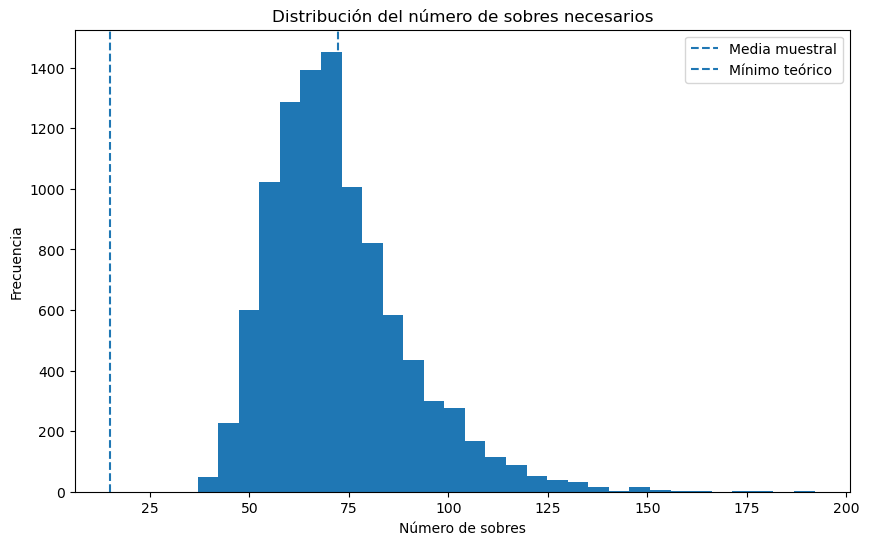

In [10]:
plt.figure(figsize=(10,6))

plt.hist(resultados_sobres, bins=30)

plt.axvline(media_sobres, linestyle='--', label='Media muestral')
plt.axvline(minimo_teorico, linestyle='--', label='Mínimo teórico')

plt.xlabel("Número de sobres")
plt.ylabel("Frecuencia")
plt.title("Distribución del número de sobres necesarios")

plt.legend()

plt.show()